<a href="https://colab.research.google.com/github/hmjisan/DAE-SAC/blob/main/DAE_SAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standard SAC


In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 42.0 MB/s eta 0:00:00


In [ ]:
!pip install gymnasium[mujoco]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 31.4 MB/s eta 0:00:00


In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')

    # THE FIX: Creates a dedicated, isolated folder for every single seed
    base_dir = f'/content/drive/MyDrive/Q1_Research_Data_1/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)

    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    # Initialize CSV if it doesn't exist
    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'Critic_Loss', 'Actor_Loss', 'Inference_ms', 'VRAM_MB'])

    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. STANDARD SAC ARCHITECTURE (THE BASELINE)
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.acts = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rews = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = obs
        self.acts[self.ptr] = act
        self.rews[self.ptr] = rew
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (torch.FloatTensor(self.obs[idxs]).to(self.device),
                torch.FloatTensor(self.acts[idxs]).to(self.device),
                torch.FloatTensor(self.rews[idxs]).to(self.device),
                torch.FloatTensor(self.next_obs[idxs]).to(self.device),
                torch.FloatTensor(self.dones[idxs]).to(self.device))

class MLPActor(nn.Module):
    def __init__(self, obs_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, obs):
        x = self.net(obs)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class MLPCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.q1 = nn.Sequential(nn.Linear(obs_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
        self.q2 = nn.Sequential(nn.Linear(obs_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))

    def forward(self, obs, act):
        xu = torch.cat([obs, act], dim=-1)
        return self.q1(xu), self.q2(xu)

# =====================================================================
# 3. SAC AGENT & OPTIMIZATION
# =====================================================================
class SACAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device):
        self.device = device
        self.actor = MLPActor(obs_dim, act_dim, action_scale).to(device)
        self.critic = MLPCritic(obs_dim, act_dim).to(device)
        self.critic_target = MLPCritic(obs_dim, act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        # PROFILING: High-precision timing for inference
        start_time = time.perf_counter()

        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        if evaluate:
            _, _, action = self.actor.sample(obs)
        else:
            action, _, _ = self.actor.sample(obs)

        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256):
        obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
        alpha = self.log_alpha.exp()

        with torch.no_grad():
            next_acts, next_log_prob, _ = self.actor.sample(next_obs)
            t_q1, t_q2 = self.critic_target(next_obs, next_acts)
            t_v = torch.min(t_q1, t_q2) - alpha * next_log_prob
            t_q = rews + (1 - dones) * 0.99 * t_v

        q1, q2 = self.critic(obs, acts)
        critic_loss = F.mse_loss(q1, t_q) + F.mse_loss(q2, t_q)
        self.critic_opt.zero_grad(); critic_loss.backward(); self.critic_opt.step()

        for p in self.critic.parameters(): p.requires_grad = False
        pi_acts, log_prob, _ = self.actor.sample(obs)
        q1_pi, q2_pi = self.critic(obs, pi_acts)
        actor_loss = (alpha.detach() * log_prob - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad(); actor_loss.backward(); self.actor_opt.step()
        for p in self.critic.parameters(): p.requires_grad = True

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(0.005 * param.data + 0.995 * target_param.data)

        return critic_loss.item(), actor_loss.item()

    def save_checkpoint(self, path, step, episode):
        # Saves to a temporary file first, then renames, preventing corruption during loadshedding
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha,
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict()
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])
            self.log_alpha = checkpoint['log_alpha']
            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])
            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # ---------------------------------------------------------
    # MANUALLY CHANGE THIS SEED FOR YOUR 5 RUNS (e.g., 42, 101, 2026, 777, 999)
    SEED = 42
    # ---------------------------------------------------------

    ALGO = "Standard_SAC"
    ENV_NAME = "BipedalWalker-v3"
    MAX_STEPS = 500_000

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)
    agent = SACAgent(obs_dim, act_dim, action_scale, device)

    # Auto-Resume Logic
    start_step, episode = agent.load_checkpoint(ckpt_path)

    obs, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_c, log_a, log_inf, updates = 0, 0, 0, 0

    print("Initiating Baseline Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action = env.action_space.sample()
            inf_ms = 0.0
        else:
            action, inf_ms = agent.select_action(obs)

        nxt, r, term, trunc, _ = env.step(action)
        ep_ext += r

        buffer.add(obs, action, r, nxt, float(term))
        obs = nxt

        if step >= 10000:
            c_loss, a_loss = agent.update(buffer)
            log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            # PROFILING: Get VRAM usage
            vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if device.type == 'cuda' else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | Inf_ms: {avg_inf:.2f} | VRAM: {vram_mb:.1f} MB")

            # Log to CSV
            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_c, avg_a, avg_inf, vram_mb])

            log_c, log_a, log_inf, updates = 0, 0, 0, 0
            ep_ext = 0
            obs, _ = env.reset()

            # Save Checkpoint every 10 episodes to limit Drive I/O
            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode)

if __name__ == "__main__":
    main()

Deploying Standard_SAC on BipedalWalker-v3 | Seed: 42 | Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initiating Baseline Training...
Step 207 | Ep 1 | Reward: -104.37 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 1807 | Ep 2 | Reward: -86.03 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 1877 | Ep 3 | Reward: -102.91 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 1956 | Ep 4 | Reward: -114.37 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 2069 | Ep 5 | Reward: -102.18 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 2146 | Ep 6 | Reward: -98.43 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 2223 | Ep 7 | Reward: -118.62 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 3823 | Ep 8 | Reward: -79.14 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 3912 | Ep 9 | Reward: -100.42 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 4012 | Ep 10 | Reward: -125.70 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 4054 | Ep 11 | Reward: -104.26 | Inf_ms: 0.00 | VRAM: 23.1 MB
Step 4138 | Ep 12 | Reward: -100.83 | Inf_ms: 

In [ ]:
!pip install gymnasium[mujoco]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 30.5 MB/s eta 0:00:00


In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')

    # THE FIX: Creates a dedicated, isolated folder for every single seed
    base_dir = f'/content/drive/MyDrive/Q1_Research_Data_1/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)

    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    # Initialize CSV if it doesn't exist
    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'Critic_Loss', 'Actor_Loss', 'Inference_ms', 'VRAM_MB'])

    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. STANDARD SAC ARCHITECTURE (THE BASELINE)
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.acts = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rews = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = obs
        self.acts[self.ptr] = act
        self.rews[self.ptr] = rew
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (torch.FloatTensor(self.obs[idxs]).to(self.device),
                torch.FloatTensor(self.acts[idxs]).to(self.device),
                torch.FloatTensor(self.rews[idxs]).to(self.device),
                torch.FloatTensor(self.next_obs[idxs]).to(self.device),
                torch.FloatTensor(self.dones[idxs]).to(self.device))

class MLPActor(nn.Module):
    def __init__(self, obs_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, obs):
        x = self.net(obs)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class MLPCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.q1 = nn.Sequential(nn.Linear(obs_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
        self.q2 = nn.Sequential(nn.Linear(obs_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))

    def forward(self, obs, act):
        xu = torch.cat([obs, act], dim=-1)
        return self.q1(xu), self.q2(xu)

# =====================================================================
# 3. SAC AGENT & OPTIMIZATION
# =====================================================================
class SACAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device):
        self.device = device
        self.actor = MLPActor(obs_dim, act_dim, action_scale).to(device)
        self.critic = MLPCritic(obs_dim, act_dim).to(device)
        self.critic_target = MLPCritic(obs_dim, act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        # PROFILING: High-precision timing for inference
        start_time = time.perf_counter()

        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        if evaluate:
            _, _, action = self.actor.sample(obs)
        else:
            action, _, _ = self.actor.sample(obs)

        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256):
        obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
        alpha = self.log_alpha.exp()

        with torch.no_grad():
            next_acts, next_log_prob, _ = self.actor.sample(next_obs)
            t_q1, t_q2 = self.critic_target(next_obs, next_acts)
            t_v = torch.min(t_q1, t_q2) - alpha * next_log_prob
            t_q = rews + (1 - dones) * 0.99 * t_v

        q1, q2 = self.critic(obs, acts)
        critic_loss = F.mse_loss(q1, t_q) + F.mse_loss(q2, t_q)
        self.critic_opt.zero_grad(); critic_loss.backward(); self.critic_opt.step()

        for p in self.critic.parameters(): p.requires_grad = False
        pi_acts, log_prob, _ = self.actor.sample(obs)
        q1_pi, q2_pi = self.critic(obs, pi_acts)
        actor_loss = (alpha.detach() * log_prob - torch.min(q1_pi, q2_pi)).mean()
        self.actor_opt.zero_grad(); actor_loss.backward(); self.actor_opt.step()
        for p in self.critic.parameters(): p.requires_grad = True

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(0.005 * param.data + 0.995 * target_param.data)

        return critic_loss.item(), actor_loss.item()

    def save_checkpoint(self, path, step, episode):
        # Saves to a temporary file first, then renames, preventing corruption during loadshedding
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha,
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict()
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])
            self.log_alpha = checkpoint['log_alpha']
            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])
            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # ---------------------------------------------------------
    # MANUALLY CHANGE THIS SEED FOR YOUR 5 RUNS (e.g., 42, 101, 2026, 777, 999)
    SEED = 42
    # ---------------------------------------------------------

    ALGO = "Standard_SAC"

    # THE FIX 1: Change to the MuJoCo Benchmark
    ENV_NAME = "Ant-v4"

    # THE FIX 2: Q1 standards require 1 Million steps for MuJoCo Continuous Control
    MAX_STEPS = 500_000

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)
    agent = SACAgent(obs_dim, act_dim, action_scale, device)

    # Auto-Resume Logic
    start_step, episode = agent.load_checkpoint(ckpt_path)

    obs, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_c, log_a, log_inf, updates = 0, 0, 0, 0

    print("Initiating Baseline Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action = env.action_space.sample()
            inf_ms = 0.0
        else:
            action, inf_ms = agent.select_action(obs)

        nxt, r, term, trunc, _ = env.step(action)
        ep_ext += r

        buffer.add(obs, action, r, nxt, float(term))
        obs = nxt

        if step >= 10000:
            c_loss, a_loss = agent.update(buffer)
            log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            # PROFILING: Get VRAM usage
            vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if device.type == 'cuda' else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | Inf_ms: {avg_inf:.2f} | VRAM: {vram_mb:.1f} MB")

            # Log to CSV
            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_c, avg_a, avg_inf, vram_mb])

            log_c, log_a, log_inf, updates = 0, 0, 0, 0
            ep_ext = 0
            obs, _ = env.reset()

            # Save Checkpoint every 10 episodes to limit Drive I/O
            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode)

if __name__ == "__main__":
    main()

Deploying Standard_SAC on Ant-v4 | Seed: 42 | Device: cuda
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Initiating Baseline Training...
Step 76 | Ep 1 | Reward: -16.72 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 95 | Ep 2 | Reward: -1.48 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 141 | Ep 3 | Reward: -12.81 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 203 | Ep 4 | Reward: -7.77 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 251 | Ep 5 | Reward: -49.37 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 276 | Ep 6 | Reward: -11.51 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 373 | Ep 7 | Reward: -25.69 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 393 | Ep 8 | Reward: 14.03 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 454 | Ep 9 | Reward: 4.53 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 504 | Ep 10 | Reward: -35.49 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 517 | Ep 11 | Reward: -9.27 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 1517 | Ep 12 | Reward: -295.00 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 1558 | Ep 13 | Reward: -26.60 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 2558 | Ep 14 | Reward: -388.54 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 3558 | Ep 15 | Reward: -322.92 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 3643 | Ep 16 

KeyboardInterrupt: 

In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')

    base_dir = f'/content/drive/MyDrive/Q1_Research_Data/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)

    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'AE_Loss', 'Critic_Loss', 'Actor_Loss', 'Inference_ms', 'VRAM_MB'])

    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. DAE-SAC CORE ARCHITECTURE (THE NOVELTY)
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.acts = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rews = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = obs
        self.acts[self.ptr] = act
        self.rews[self.ptr] = rew
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (torch.FloatTensor(self.obs[idxs]).to(self.device),
                torch.FloatTensor(self.acts[idxs]).to(self.device),
                torch.FloatTensor(self.rews[idxs]).to(self.device),
                torch.FloatTensor(self.next_obs[idxs]).to(self.device),
                torch.FloatTensor(self.dones[idxs]).to(self.device))

# THE FIX 1: Restored RunningNorm to protect AE from MuJoCo variance
class RunningNorm(nn.Module):
    def __init__(self, latent_dim, momentum=0.99):
        super().__init__()
        self.momentum = momentum
        self.register_buffer('running_mean', torch.zeros(latent_dim))
        self.register_buffer('running_var', torch.ones(latent_dim))

    def forward(self, x, update_stats=True):
        mean, var = self.running_mean.clone(), self.running_var.clone()
        if self.training and update_stats:
            with torch.no_grad():
                dim_avg = (0, 1) if x.dim() == 3 else 0
                batch_mean = x.mean(dim=dim_avg)
                batch_var = x.var(dim=dim_avg, unbiased=False)
                self.running_mean.copy_(self.momentum * self.running_mean + (1 - self.momentum) * batch_mean)
                self.running_var.copy_(self.momentum * self.running_var + (1 - self.momentum) * batch_var)
        return (x - mean) / torch.sqrt(var + 1e-5)

class Autoencoder(nn.Module):
    def __init__(self, obs_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, obs_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x)

class SACActor(nn.Module):
    def __init__(self, latent_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, z):
        x = self.net(z)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class SACCritic(nn.Module):
    def __init__(self, latent_dim, act_dim):
        super().__init__()
        self.q1 = nn.Sequential(nn.Linear(latent_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
        self.q2 = nn.Sequential(nn.Linear(latent_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))

    def forward(self, z, act):
        xu = torch.cat([z, act], dim=-1)
        return self.q1(xu), self.q2(xu)

# =====================================================================
# 3. DAE-SAC AGENT & OPTIMIZATION
# =====================================================================
class DAESACAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device, latent_dim=16):
        self.device = device

        self.obs_norm = RunningNorm(obs_dim).to(device)
        self.ae = Autoencoder(obs_dim, latent_dim).to(device)
        self.actor = SACActor(latent_dim, act_dim, action_scale).to(device)
        self.critic = SACCritic(latent_dim, act_dim).to(device)
        self.critic_target = SACCritic(latent_dim, act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        # Optimizers include parameters for normalization scaling if needed
        self.ae_opt = optim.Adam(list(self.ae.parameters()) + list(self.obs_norm.parameters()), lr=1e-3)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        start_time = time.perf_counter()

        self.ae.eval() # Ensure eval mode for live inference
        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            normed_obs = self.obs_norm(obs, update_stats=False)
            z = self.ae.encode(normed_obs)
            if evaluate:
                _, _, action = self.actor.sample(z)
            else:
                action, _, _ = self.actor.sample(z)

        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256):
        self.ae.train()
        obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
        alpha = self.log_alpha.exp()

        # 1. Update Autoencoder (State Compression on Normalized Data)
        normed_obs = self.obs_norm(obs, update_stats=True)
        rec_obs = self.ae(normed_obs)
        ae_loss = F.mse_loss(rec_obs, normed_obs)

        self.ae_opt.zero_grad()
        ae_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.ae.parameters(), 1.0) # THE FIX 2: Surge Protection
        self.ae_opt.step()

        # THE FIREWALL: Detach z so RL gradients DO NOT corrupt the representation
        with torch.no_grad():
            z = self.ae.encode(normed_obs).detach()

            normed_next_obs = self.obs_norm(next_obs, update_stats=False)
            next_z = self.ae.encode(normed_next_obs).detach()

            next_acts, next_log_prob, _ = self.actor.sample(next_z)
            t_q1, t_q2 = self.critic_target(next_z, next_acts)
            t_v = torch.min(t_q1, t_q2) - alpha * next_log_prob
            t_q = rews + (1 - dones) * 0.99 * t_v

        # 2. Update Critic
        q1, q2 = self.critic(z, acts)
        critic_loss = F.mse_loss(q1, t_q) + F.mse_loss(q2, t_q)

        self.critic_opt.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0) # THE FIX 2: Surge Protection
        self.critic_opt.step()

        # 3. Update Actor
        for p in self.critic.parameters(): p.requires_grad = False
        pi_acts, log_prob, _ = self.actor.sample(z)
        q1_pi, q2_pi = self.critic(z, pi_acts)
        actor_loss = (alpha.detach() * log_prob - torch.min(q1_pi, q2_pi)).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0) # THE FIX 2: Surge Protection
        self.actor_opt.step()
        for p in self.critic.parameters(): p.requires_grad = True

        # 4. Update Alpha
        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()

        # 5. Polyak Averaging
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(0.005 * param.data + 0.995 * target_param.data)

        return ae_loss.item(), critic_loss.item(), actor_loss.item()

    def save_checkpoint(self, path, step, episode):
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'obs_norm': self.obs_norm.state_dict(),
            'ae': self.ae.state_dict(),
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha,
            'ae_opt': self.ae_opt.state_dict(),
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict()
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.obs_norm.load_state_dict(checkpoint['obs_norm'])
            self.ae.load_state_dict(checkpoint['ae'])
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])
            self.log_alpha = checkpoint['log_alpha']
            self.ae_opt.load_state_dict(checkpoint['ae_opt'])
            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])
            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0

# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # ---------------------------------------------------------
    # MANUALLY CHANGE THIS SEED FOR YOUR 5 RUNS (e.g., 42, 101, 2026, 777, 999)
    SEED = 777
    # ---------------------------------------------------------

    ALGO = "DAE_SAC"
    ENV_NAME = "Hopper-v4" # THE FIX: Switching to MuJoCo
    MAX_STEPS = 300_000

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)

    # Compress 17D Cheetah observation down to a 16D dense vector
    agent = DAESACAgent(obs_dim, act_dim, action_scale, device, latent_dim=16)

    start_step, episode = agent.load_checkpoint(ckpt_path)

    obs, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_ae, log_c, log_a, log_inf, updates = 0, 0, 0, 0, 0

    print("Initiating DAE-SAC Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action = env.action_space.sample()
            inf_ms = 0.0
        else:
            action, inf_ms = agent.select_action(obs)

        nxt, r, term, trunc, _ = env.step(action)
        ep_ext += r

        buffer.add(obs, action, r, nxt, float(term))
        obs = nxt

        if step >= 10000:
            ae_loss, c_loss, a_loss = agent.update(buffer)
            log_ae += ae_loss; log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_ae = log_ae / updates if updates > 0 else 0
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if device.type == 'cuda' else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | AE Loss: {avg_ae:.4f} | Inf_ms: {avg_inf:.2f} | VRAM: {vram_mb:.1f} MB")

            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_ae, avg_c, avg_a, avg_inf, vram_mb])

            log_ae, log_c, log_a, log_inf, updates = 0, 0, 0, 0, 0
            ep_ext = 0
            obs, _ = env.reset()

            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode)

if __name__ == "__main__":
    main()

Deploying DAE_SAC on Hopper-v4 | Seed: 777 | Device: cuda
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


RESUMING TRAINING FROM STEP 163380
Initiating DAE-SAC Training...
Step 163485 | Ep 1141 | Reward: 185.12 | AE Loss: 0.0010 | Inf_ms: 6.19 | VRAM: 23.1 MB
Step 163699 | Ep 1142 | Reward: 348.98 | AE Loss: 0.0001 | Inf_ms: 1.53 | VRAM: 23.1 MB
Step 163897 | Ep 1143 | Reward: 334.55 | AE Loss: 0.0000 | Inf_ms: 1.31 | VRAM: 23.1 MB
Step 163924 | Ep 1144 | Reward: 44.91 | AE Loss: 0.0000 | Inf_ms: 1.25 | VRAM: 23.1 MB
Step 163952 | Ep 1145 | Reward: 46.39 | AE Loss: 0.0000 | Inf_ms: 1.29 | VRAM: 23.1 MB
Step 164019 | Ep 1146 | Reward: 109.84 | AE Loss: 0.0000 | Inf_ms: 1.24 | VRAM: 23.1 MB
Step 164085 | Ep 1147 | Reward: 106.17 | AE Loss: 0.0000 | Inf_ms: 1.18 | VRAM: 23.1 MB
Step 164145 | Ep 1148 | Reward: 96.55 | AE Loss: 0.0000 | Inf_ms: 1.23 | VRAM: 23.1 MB
Step 164256 | Ep 1149 | Reward: 160.72 | AE Loss: 0.0000 | Inf_ms: 1.25 | VRAM: 23.1 MB
Step 164285 | Ep 1150 | Reward: 50.16 | AE Loss: 0.0000 | Inf_ms: 1.17 | VRAM: 23.1 MB
Step 164364 | Ep 1151 | Reward: 114.89 | AE Loss: 0.0000 |

Mounted at /content/drive
Aggregating data and generating plots...

Success! High-resolution 300k plot saved to: /content/drive/MyDrive/Q1_Research_Data/Main_Results_Plot_300k.png


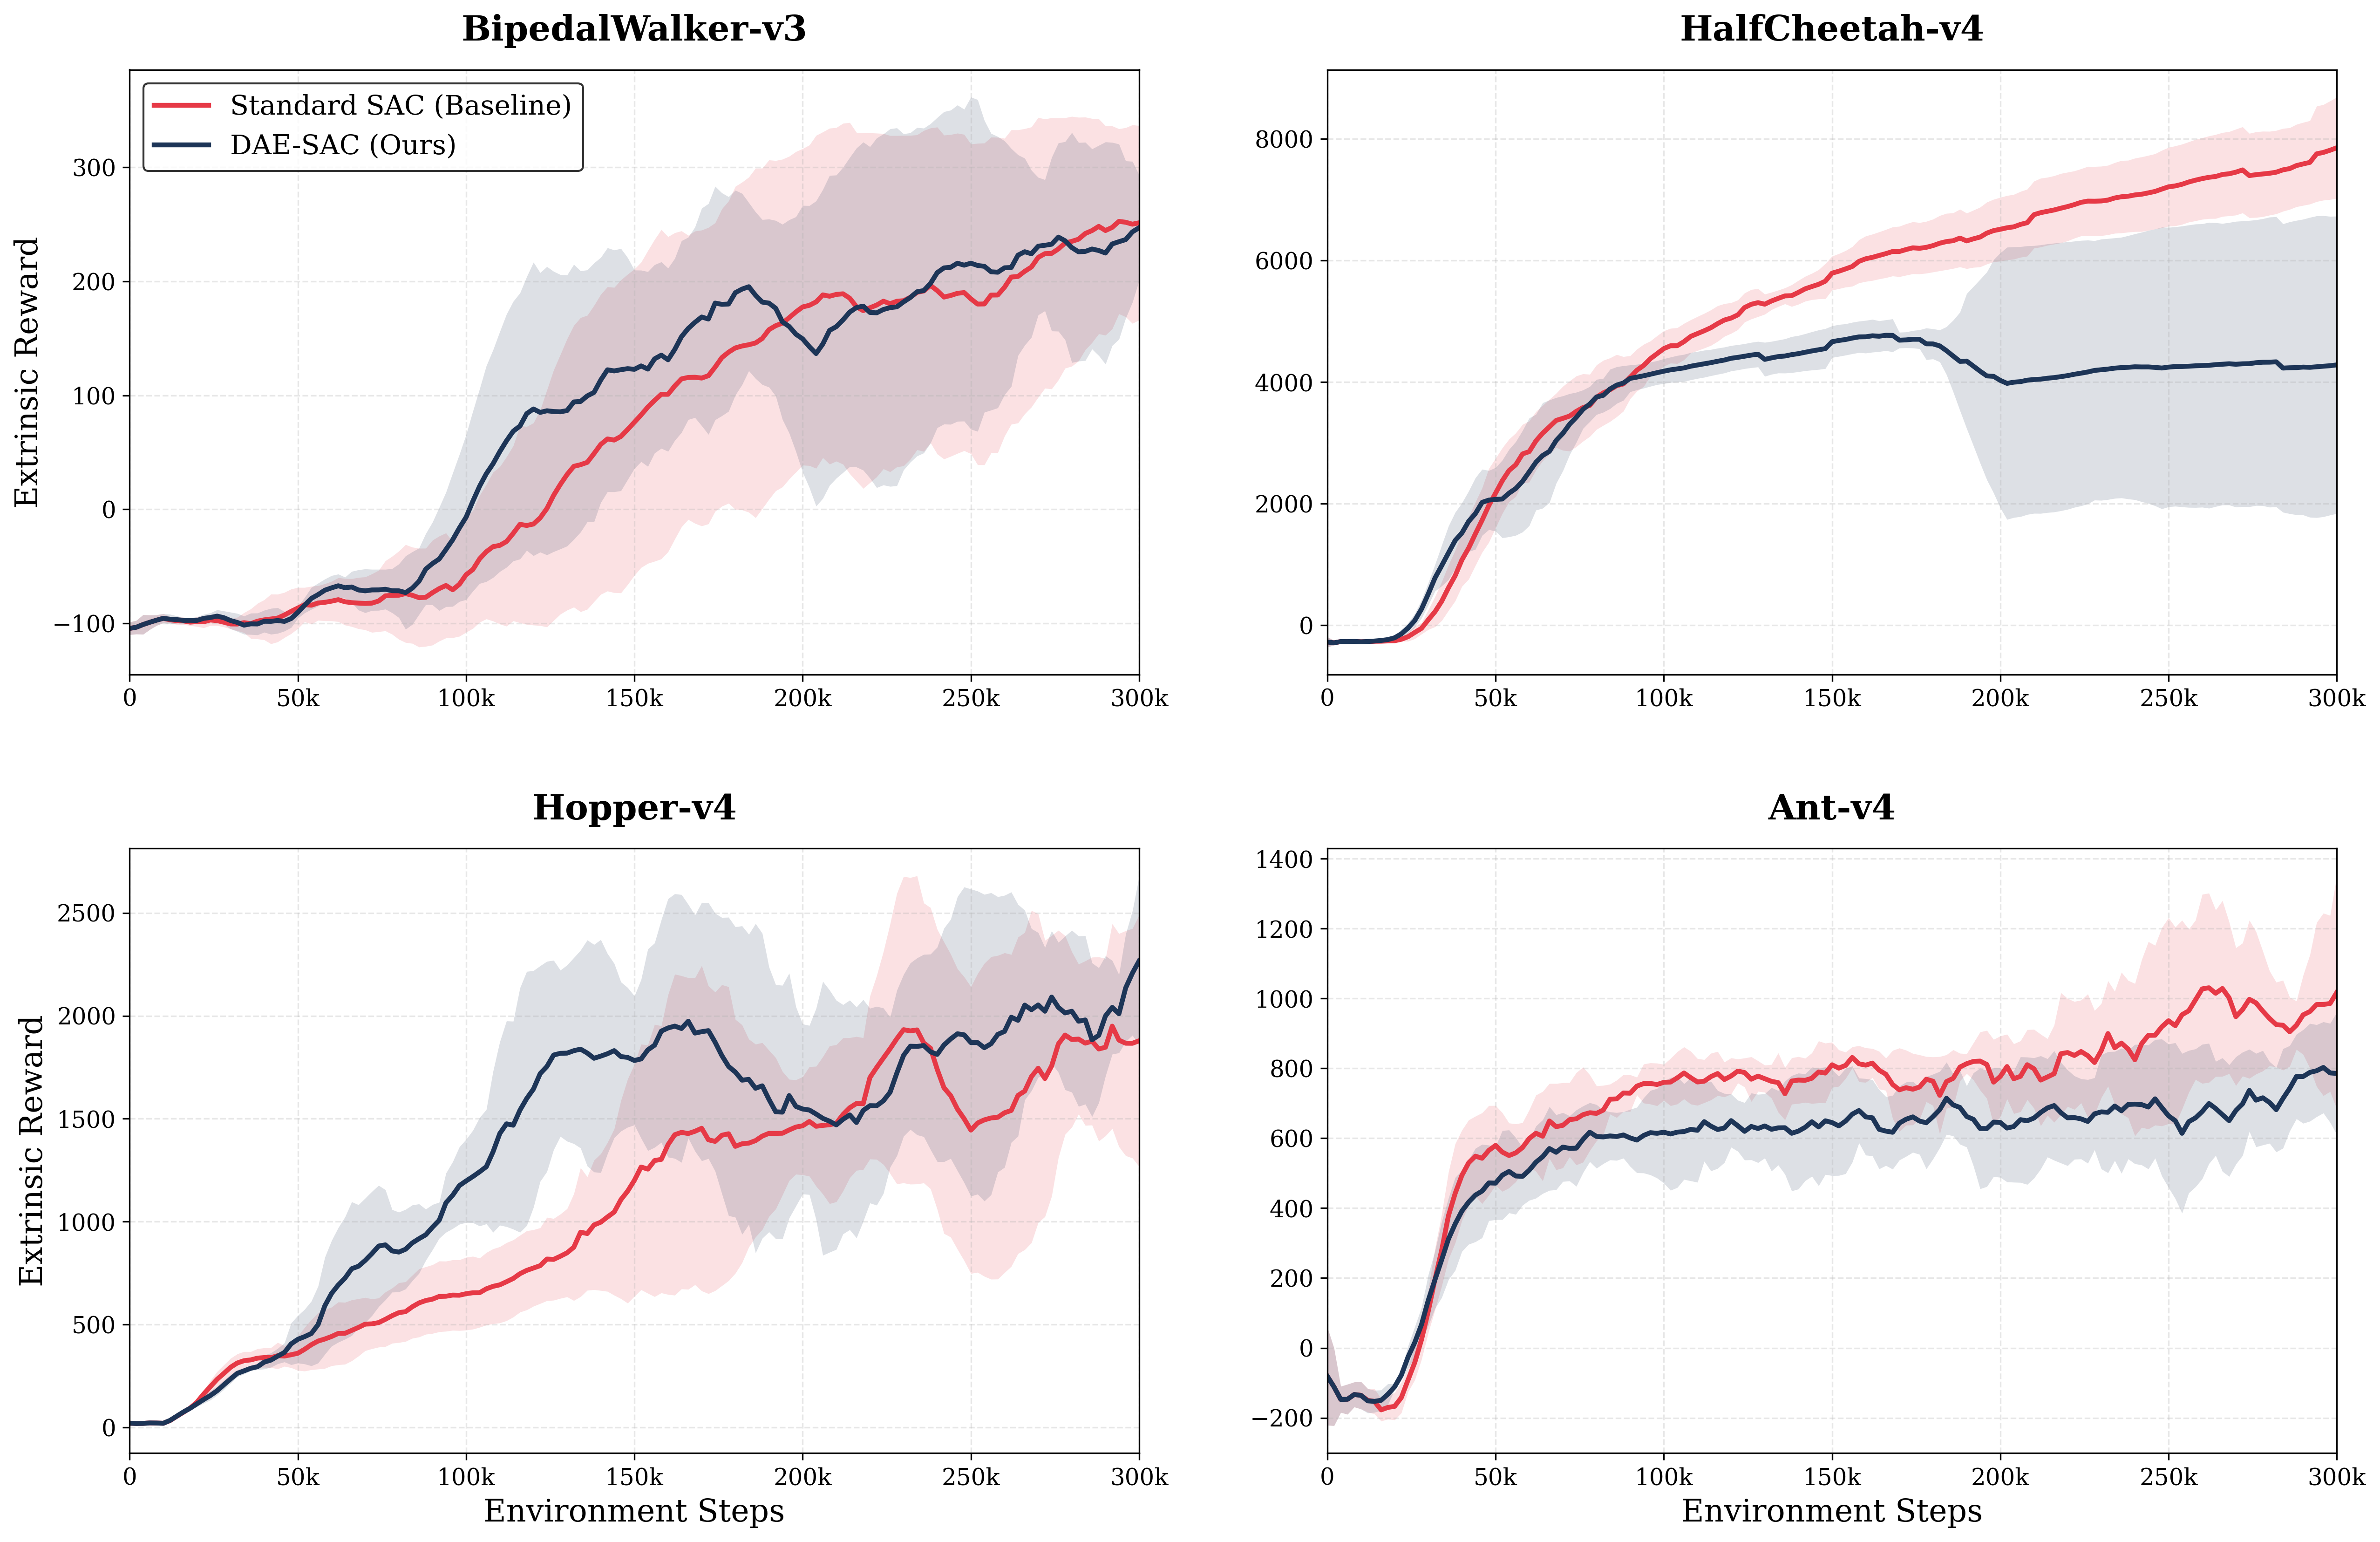

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Publication-Quality Formatting Settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'lines.linewidth': 2.5,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 3. Definitions
ALGORITHMS = {
    "Standard_SAC": {"label": "Standard SAC (Baseline)", "color": "#E63946"}, # Crimson Red
    "DAE_SAC": {"label": "DAE-SAC (Ours)", "color": "#1D3557"}                 # Deep Navy Blue
}

ENVIRONMENTS = [
    "BipedalWalker-v3",
    "HalfCheetah-v4",
    "Hopper-v4",
    "Ant-v4"
]

SEEDS = [42, 101, 777, 999, 2026]

# THE FIX: Clipped the global evaluation horizon to 300k steps
MAX_STEPS = 300_000
RESOLUTION = 2_000
SMOOTHING_WINDOW = 10

def load_and_process_data(algo, env, seeds):
    """Loads CSVs, interpolates to a common step grid, and calculates mean/std."""
    grid = np.arange(0, MAX_STEPS + RESOLUTION, RESOLUTION)
    all_runs = []

    for seed in seeds:
        path = f'/content/drive/MyDrive/Q1_Research_Data/{algo}/{env}/Seed_{seed}/training_log.csv'
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                df = df.drop_duplicates(subset=['Step']).sort_values('Step')

                # Only keep data up to our new MAX_STEPS to prevent interpolation weirdness
                df = df[df['Step'] <= MAX_STEPS + RESOLUTION]

                if len(df) > 5:
                    interp_rewards = np.interp(grid, df['Step'], df['Reward'])
                    all_runs.append(interp_rewards)
            except Exception as e:
                print(f"Error loading {path}: {e}")

    if not all_runs:
        return grid, None, None

    all_runs_matrix = np.vstack(all_runs)
    df_smooth = pd.DataFrame(all_runs_matrix.T).rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()

    mean_rewards = df_smooth.mean(axis=1).values
    std_rewards = df_smooth.std(axis=1).values

    return grid, mean_rewards, std_rewards

def generate_publication_plot():
    print("Aggregating data and generating plots...")
    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    axs = axs.flatten()

    for idx, env in enumerate(ENVIRONMENTS):
        ax = axs[idx]
        ax.set_title(env, fontweight='bold', pad=15)

        for algo_key, algo_props in ALGORITHMS.items():
            steps, mean_rew, std_rew = load_and_process_data(algo_key, env, SEEDS)

            if mean_rew is not None:
                ax.plot(steps, mean_rew, label=algo_props["label"], color=algo_props["color"])
                ax.fill_between(steps,
                                mean_rew - std_rew,
                                mean_rew + std_rew,
                                color=algo_props["color"],
                                alpha=0.15,
                                linewidth=0)
            else:
                print(f"Warning: No data found for {algo_key} on {env}")

        # Formatting the axes to strictly end at 300k
        ax.set_xlim(0, MAX_STEPS)

        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))

        if idx >= 2:
            ax.set_xlabel("Environment Steps")
        if idx % 2 == 0:
            ax.set_ylabel("Extrinsic Reward")

        if idx == 0:
            ax.legend(loc="upper left", frameon=True, fancybox=True, shadow=False, edgecolor='black')

    plt.tight_layout(pad=3.0)

    save_path = '/content/drive/MyDrive/Q1_Research_Data/Main_Results_Plot_300k.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"\nSuccess! High-resolution 300k plot saved to: {save_path}")

    plt.show()

if __name__ == "__main__":
    generate_publication_plot()

In [ ]:
import os
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gymnasium as gym
from google.colab import drive

# =====================================================================
# 1. GOOGLE DRIVE & STRICT SEED ISOLATION
# =====================================================================
def setup_drive_and_paths(algo_name, env_name, seed):
    drive.mount('/content/drive')

    base_dir = f'/content/drive/MyDrive/Q1_Research_Data/{algo_name}/{env_name}/Seed_{seed}'
    os.makedirs(base_dir, exist_ok=True)

    csv_path = os.path.join(base_dir, 'training_log.csv')
    ckpt_path = os.path.join(base_dir, 'checkpoint.pth')

    if not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Step', 'Episode', 'Reward', 'AE_Loss', 'Critic_Loss', 'Actor_Loss', 'Inference_ms', 'VRAM_MB'])

    return csv_path, ckpt_path

def set_all_seeds(seed, env):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    env.action_space.seed(seed)
    env.observation_space.seed(seed)

# =====================================================================
# 2. DAE-SAC CORE ARCHITECTURE (THE NOVELTY)
# =====================================================================
class ReplayBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.acts = np.zeros((capacity, act_dim), dtype=np.float32)
        self.rews = np.zeros((capacity, 1), dtype=np.float32)
        self.next_obs = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.capacity, self.ptr, self.size = capacity, 0, 0
        self.device = device

    def add(self, obs, act, rew, next_obs, done):
        self.obs[self.ptr] = obs
        self.acts[self.ptr] = act
        self.rews[self.ptr] = rew
        self.next_obs[self.ptr] = next_obs
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)
        return (torch.FloatTensor(self.obs[idxs]).to(self.device),
                torch.FloatTensor(self.acts[idxs]).to(self.device),
                torch.FloatTensor(self.rews[idxs]).to(self.device),
                torch.FloatTensor(self.next_obs[idxs]).to(self.device),
                torch.FloatTensor(self.dones[idxs]).to(self.device))

# THE FIX 1: Restored RunningNorm to protect AE from MuJoCo variance
class RunningNorm(nn.Module):
    def __init__(self, latent_dim, momentum=0.99):
        super().__init__()
        self.momentum = momentum
        self.register_buffer('running_mean', torch.zeros(latent_dim))
        self.register_buffer('running_var', torch.ones(latent_dim))

    def forward(self, x, update_stats=True):
        mean, var = self.running_mean.clone(), self.running_var.clone()
        if self.training and update_stats:
            with torch.no_grad():
                dim_avg = (0, 1) if x.dim() == 3 else 0
                batch_mean = x.mean(dim=dim_avg)
                batch_var = x.var(dim=dim_avg, unbiased=False)
                self.running_mean.copy_(self.momentum * self.running_mean + (1 - self.momentum) * batch_mean)
                self.running_var.copy_(self.momentum * self.running_var + (1 - self.momentum) * batch_var)
        return (x - mean) / torch.sqrt(var + 1e-5)

class Autoencoder(nn.Module):
    def __init__(self, obs_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, obs_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x)

class SACActor(nn.Module):
    def __init__(self, latent_dim, act_dim, action_scale):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU())
        self.mean_linear = nn.Linear(256, act_dim)
        self.log_std_linear = nn.Linear(256, act_dim)
        self.action_scale = action_scale

    def sample(self, z):
        x = self.net(z)
        mean, log_std = self.mean_linear(x), self.log_std_linear(x)
        log_std = torch.clamp(log_std, min=-20, max=2)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        x_t = normal.rsample()
        y_t = torch.tanh(x_t)
        action = y_t * self.action_scale
        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(self.action_scale * (1 - y_t.pow(2)) + 1e-6)
        return action, log_prob.sum(dim=-1, keepdim=True), torch.tanh(mean) * self.action_scale

class SACCritic(nn.Module):
    def __init__(self, latent_dim, act_dim):
        super().__init__()
        self.q1 = nn.Sequential(nn.Linear(latent_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))
        self.q2 = nn.Sequential(nn.Linear(latent_dim + act_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 1))

    def forward(self, z, act):
        xu = torch.cat([z, act], dim=-1)
        return self.q1(xu), self.q2(xu)

# =====================================================================
# 3. DAE-SAC AGENT & OPTIMIZATION (ABLATED - COUPLED GRADIENTS)
# =====================================================================
class DAESACAgent:
    def __init__(self, obs_dim, act_dim, action_scale, device, latent_dim=16):
        self.device = device

        self.obs_norm = RunningNorm(obs_dim).to(device)
        self.ae = Autoencoder(obs_dim, latent_dim).to(device)
        self.actor = SACActor(latent_dim, act_dim, action_scale).to(device)
        self.critic = SACCritic(latent_dim, act_dim).to(device)
        self.critic_target = SACCritic(latent_dim, act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.ae_opt = optim.Adam(list(self.ae.parameters()) + list(self.obs_norm.parameters()), lr=1e-3)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=3e-4)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=3e-4)

        self.target_entropy = -act_dim
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_opt = optim.Adam([self.log_alpha], lr=3e-4)

    def select_action(self, obs, evaluate=False):
        start_time = time.perf_counter()

        self.ae.eval()
        obs = torch.FloatTensor(obs).unsqueeze(0).to(self.device)
        with torch.no_grad():
            normed_obs = self.obs_norm(obs, update_stats=False)
            z = self.ae.encode(normed_obs)
            if evaluate:
                _, _, action = self.actor.sample(z)
            else:
                action, _, _ = self.actor.sample(z)

        inf_time_ms = (time.perf_counter() - start_time) * 1000
        return action.detach().cpu().numpy()[0], inf_time_ms

    def update(self, buffer, batch_size=256):
        self.ae.train()
        obs, acts, rews, next_obs, dones = buffer.sample(batch_size)
        alpha = self.log_alpha.exp()

        normed_obs = self.obs_norm(obs, update_stats=True)
        rec_obs = self.ae(normed_obs)
        ae_loss = F.mse_loss(rec_obs, normed_obs)

        # THE ABLATION: Firewall Destroyed. No more .detach()
        z = self.ae.encode(normed_obs)

        with torch.no_grad():
            normed_next_obs = self.obs_norm(next_obs, update_stats=False)
            next_z = self.ae.encode(normed_next_obs).detach()

            next_acts, next_log_prob, _ = self.actor.sample(next_z)
            t_q1, t_q2 = self.critic_target(next_z, next_acts)
            t_v = torch.min(t_q1, t_q2) - alpha * next_log_prob
            t_q = rews + (1 - dones) * 0.99 * t_v

        q1, q2 = self.critic(z, acts)
        critic_loss = F.mse_loss(q1, t_q) + F.mse_loss(q2, t_q)

        self.critic_opt.zero_grad()
        critic_loss.backward(retain_graph=True)
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_opt.step()

        for p in self.critic.parameters(): p.requires_grad = False
        pi_acts, log_prob, _ = self.actor.sample(z)
        q1_pi, q2_pi = self.critic(z, pi_acts)
        actor_loss = (alpha.detach() * log_prob - torch.min(q1_pi, q2_pi)).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward(retain_graph=True)
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_opt.step()
        for p in self.critic.parameters(): p.requires_grad = True

        # Apply AE loss and step the AE optimizer with ALL accumulated gradients
        self.ae_opt.zero_grad()
        ae_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.ae.parameters(), 1.0)
        self.ae_opt.step()

        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        self.alpha_opt.zero_grad(); alpha_loss.backward(); self.alpha_opt.step()

        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(0.005 * param.data + 0.995 * target_param.data)

        return ae_loss.item(), critic_loss.item(), actor_loss.item()

    def save_checkpoint(self, path, step, episode):
        tmp_path = path + ".tmp"
        torch.save({
            'step': step,
            'episode': episode,
            'obs_norm': self.obs_norm.state_dict(),
            'ae': self.ae.state_dict(),
            'actor': self.actor.state_dict(),
            'critic': self.critic.state_dict(),
            'log_alpha': self.log_alpha,
            'ae_opt': self.ae_opt.state_dict(),
            'actor_opt': self.actor_opt.state_dict(),
            'critic_opt': self.critic_opt.state_dict(),
            'alpha_opt': self.alpha_opt.state_dict()
        }, tmp_path)
        os.replace(tmp_path, path)

    def load_checkpoint(self, path):
        if os.path.exists(path):
            checkpoint = torch.load(path)
            self.obs_norm.load_state_dict(checkpoint['obs_norm'])
            self.ae.load_state_dict(checkpoint['ae'])
            self.actor.load_state_dict(checkpoint['actor'])
            self.critic.load_state_dict(checkpoint['critic'])
            self.critic_target.load_state_dict(checkpoint['critic'])
            self.log_alpha = checkpoint['log_alpha']
            self.ae_opt.load_state_dict(checkpoint['ae_opt'])
            self.actor_opt.load_state_dict(checkpoint['actor_opt'])
            self.critic_opt.load_state_dict(checkpoint['critic_opt'])
            self.alpha_opt.load_state_dict(checkpoint['alpha_opt'])
            print(f"RESUMING TRAINING FROM STEP {checkpoint['step']}")
            return checkpoint['step'], checkpoint['episode']
        return 0, 0


# =====================================================================
# 4. EXECUTION LOOP
# =====================================================================
def main():
    # ---------------------------------------------------------
    # RUN THIS FOR SEEDS: 42, 101, 777
    SEED = 42
    # ---------------------------------------------------------

    ALGO = "Coupled_AE_SAC" # THE ABLATION: New folder to prevent overwriting
    ENV_NAME = "Ant-v4"
    MAX_STEPS = 300_000 # THE ABLATION: Only run to 300k to save compute

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Deploying {ALGO} on {ENV_NAME} | Seed: {SEED} | Device: {device}")

    csv_path, ckpt_path = setup_drive_and_paths(ALGO, ENV_NAME, SEED)

    # ... [Rest of the standard initialization code remains exactly the same] ...

    env = gym.make(ENV_NAME)
    set_all_seeds(SEED, env)

    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    action_scale = float(env.action_space.high[0])

    buffer = ReplayBuffer(1_000_000, obs_dim, act_dim, device)

    # Compress the chaotic 27D Ant observation down to a stable 16D dense vector
    agent = DAESACAgent(obs_dim, act_dim, action_scale, device, latent_dim=16)

    start_step, episode = agent.load_checkpoint(ckpt_path)

    obs, _ = env.reset(seed=SEED)
    ep_ext = 0
    log_ae, log_c, log_a, log_inf, updates = 0, 0, 0, 0, 0

    print("Initiating DAE-SAC Training...")

    for step in range(start_step, MAX_STEPS):
        if step < 10000 and start_step == 0:
            action = env.action_space.sample()
            inf_ms = 0.0
        else:
            action, inf_ms = agent.select_action(obs)

        nxt, r, term, trunc, _ = env.step(action)
        ep_ext += r

        buffer.add(obs, action, r, nxt, float(term))
        obs = nxt

        if step >= 10000:
            ae_loss, c_loss, a_loss = agent.update(buffer)
            log_ae += ae_loss; log_c += c_loss; log_a += a_loss; log_inf += inf_ms; updates += 1

        if term or trunc:
            episode += 1
            avg_ae = log_ae / updates if updates > 0 else 0
            avg_c = log_c / updates if updates > 0 else 0
            avg_a = log_a / updates if updates > 0 else 0
            avg_inf = log_inf / updates if updates > 0 else 0

            vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2) if device.type == 'cuda' else 0

            print(f"Step {step} | Ep {episode} | Reward: {ep_ext:.2f} | AE Loss: {avg_ae:.4f} | Inf_ms: {avg_inf:.2f} | VRAM: {vram_mb:.1f} MB")

            with open(csv_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([step, episode, ep_ext, avg_ae, avg_c, avg_a, avg_inf, vram_mb])

            log_ae, log_c, log_a, log_inf, updates = 0, 0, 0, 0, 0
            ep_ext = 0
            obs, _ = env.reset()

            if episode % 10 == 0:
                agent.save_checkpoint(ckpt_path, step, episode)

if __name__ == "__main__":
    main()

Deploying Coupled_AE_SAC on Ant-v4 | Seed: 42 | Device: cuda
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Initiating DAE-SAC Training...
Step 76 | Ep 1 | Reward: -16.72 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 95 | Ep 2 | Reward: -1.48 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 141 | Ep 3 | Reward: -12.81 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 203 | Ep 4 | Reward: -7.77 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 251 | Ep 5 | Reward: -49.37 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 276 | Ep 6 | Reward: -11.51 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 373 | Ep 7 | Reward: -25.69 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 393 | Ep 8 | Reward: 14.03 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 454 | Ep 9 | Reward: 4.53 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 504 | Ep 10 | Reward: -35.49 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 517 | Ep 11 | Reward: -9.27 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB
Step 1517 | Ep 12 | Reward: -295.00 | AE Loss: 0.0000 | Inf_ms: 0.00 | VRAM: 1.4 MB


Mounted at /content/drive
Aggregating data and generating plots...
Success! Vector PDF saved to: /content/drive/MyDrive/Q1_Research_Data/Main_Results_Plot_300k.pdf


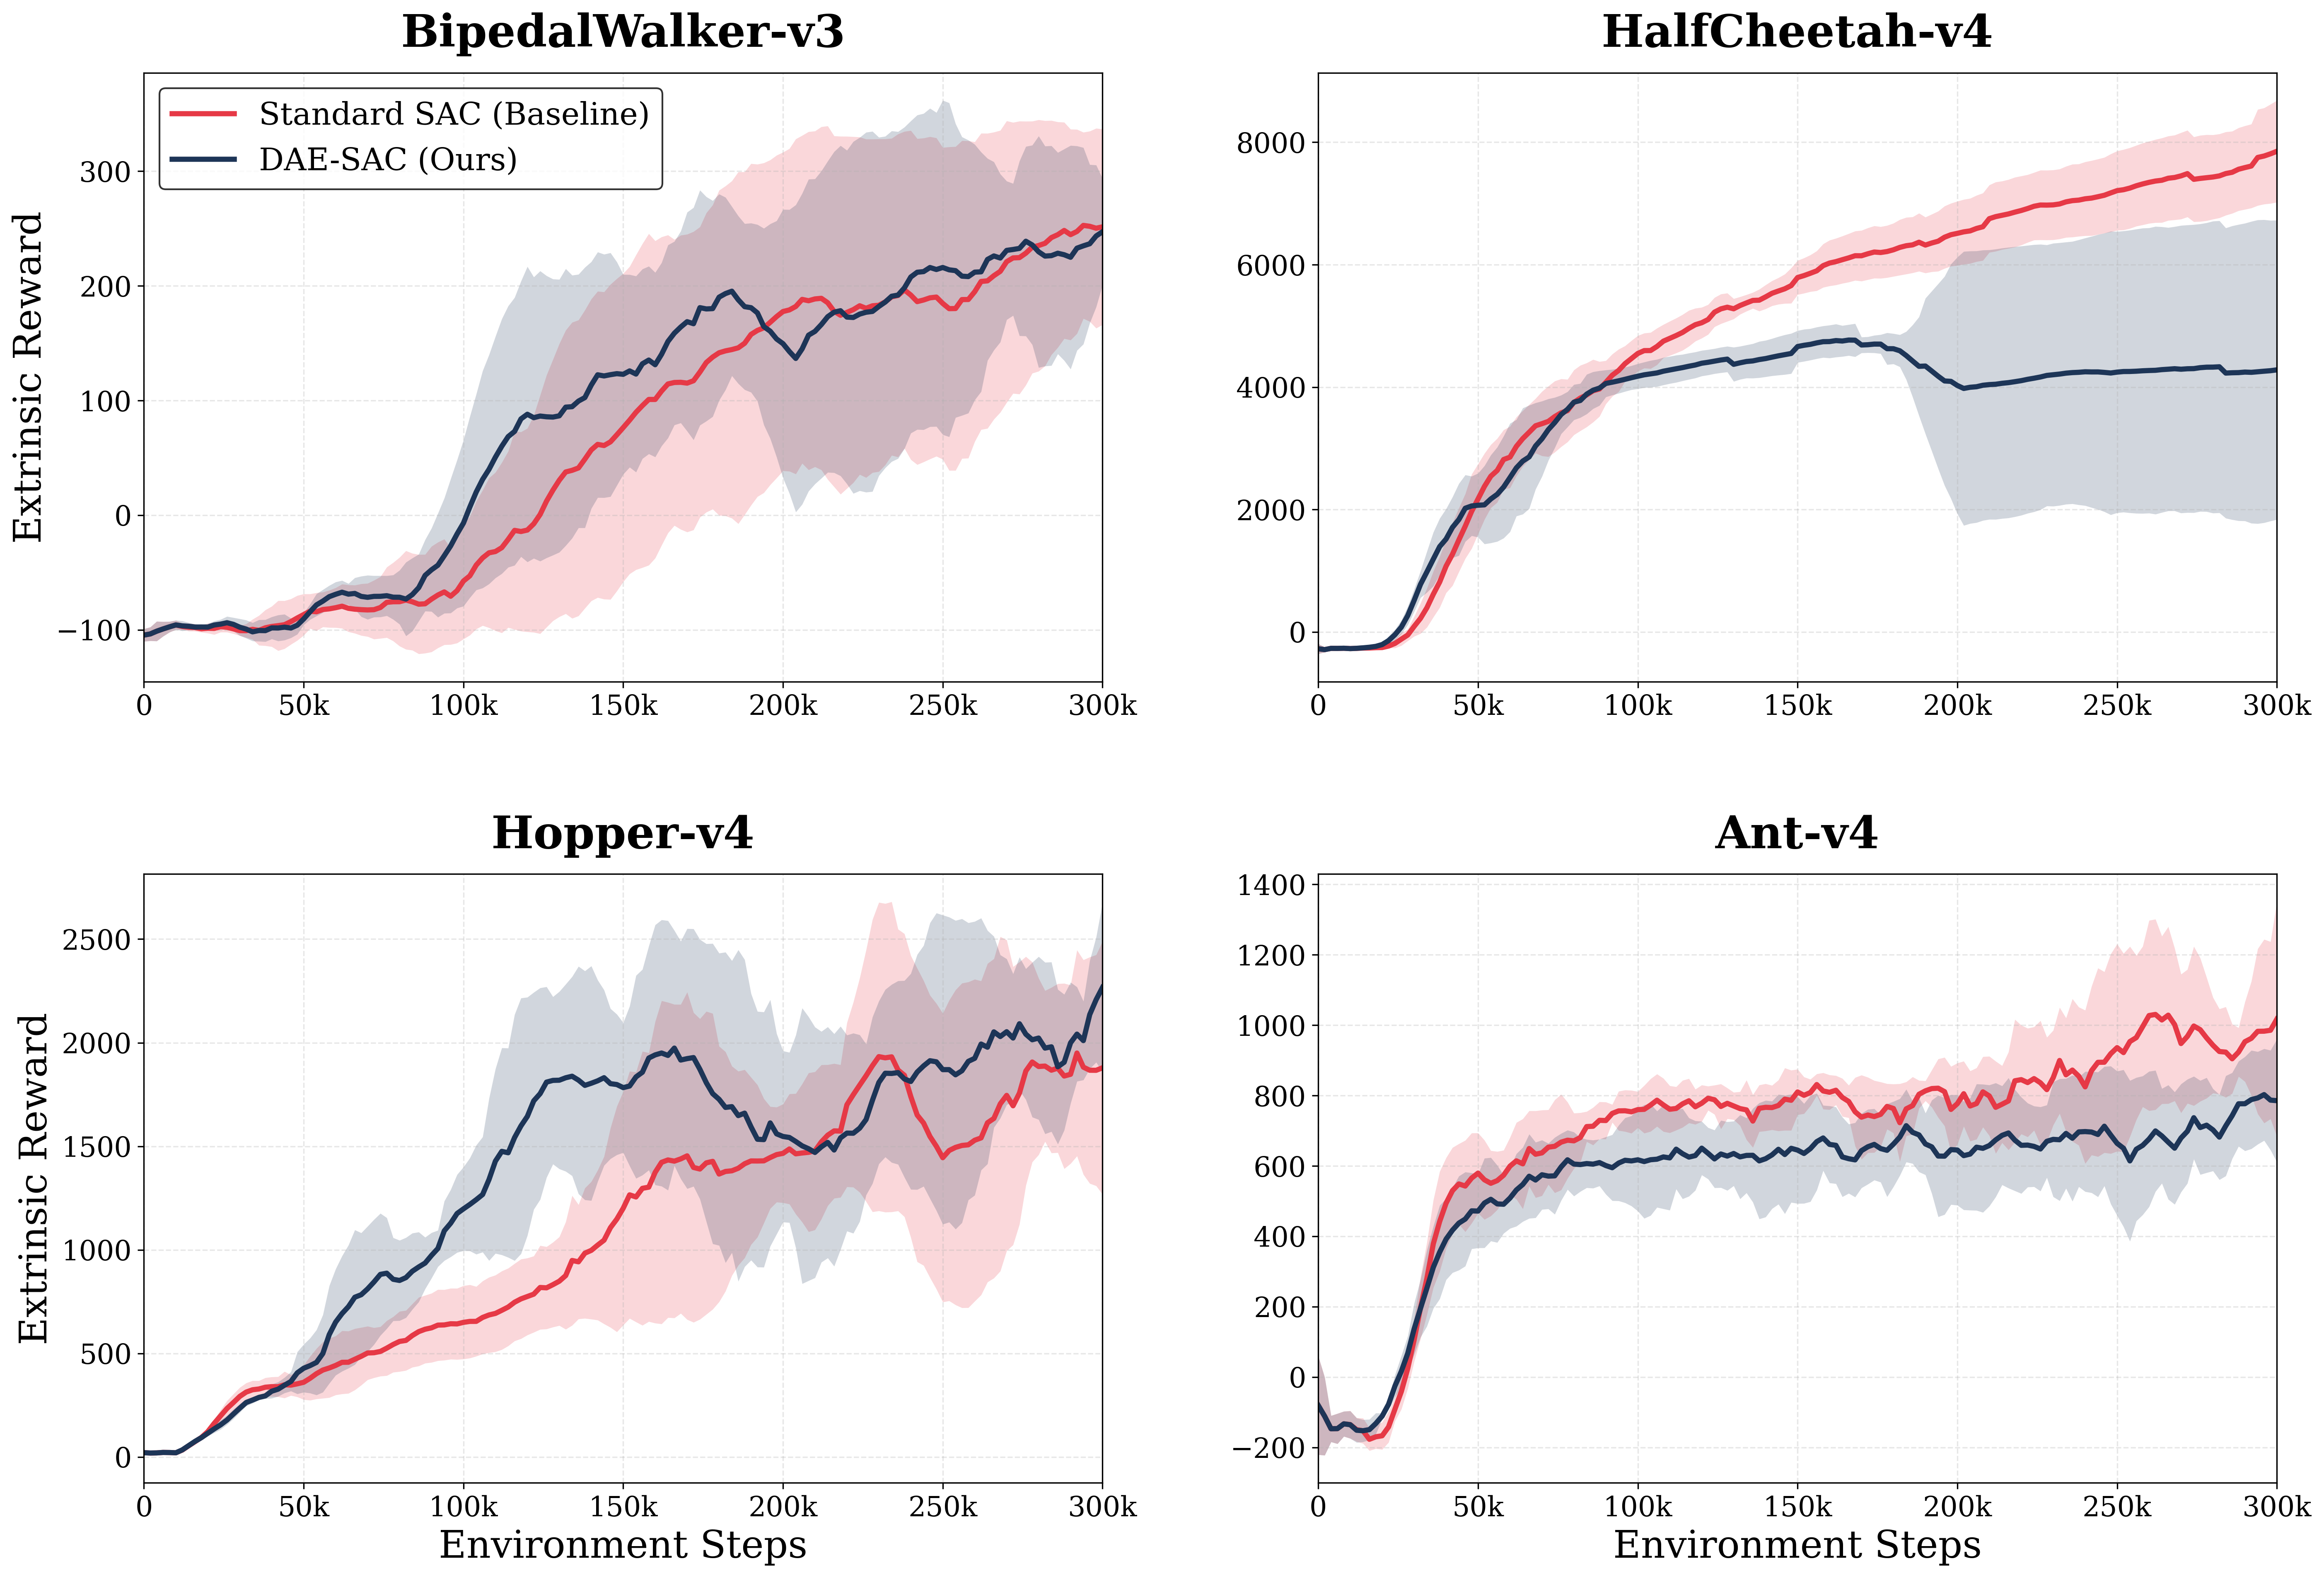

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Publication-Quality Formatting Settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,               # INCREASED
    'axes.labelsize': 22,          # INCREASED
    'axes.titlesize': 26,          # INCREASED
    'legend.fontsize': 18,         # INCREASED
    'xtick.labelsize': 16,         # INCREASED
    'ytick.labelsize': 16,         # INCREASED
    'lines.linewidth': 3.0,        # Slightly thicker lines to match larger text
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 3. Definitions
ALGORITHMS = {
    "Standard_SAC": {"label": "Standard SAC (Baseline)", "color": "#E63946"}, # Crimson Red
    "DAE_SAC": {"label": "DAE-SAC (Ours)", "color": "#1D3557"}                 # Deep Navy Blue
}

ENVIRONMENTS = [
    "BipedalWalker-v3",
    "HalfCheetah-v4",
    "Hopper-v4",
    "Ant-v4"
]

SEEDS = [42, 101, 777, 999, 2026]

# THE FIX: Clipped the global evaluation horizon to 300k steps
MAX_STEPS = 300_000
RESOLUTION = 2_000
SMOOTHING_WINDOW = 10

def load_and_process_data(algo, env, seeds):
    """Loads CSVs, interpolates to a common step grid, and calculates mean/std."""
    grid = np.arange(0, MAX_STEPS + RESOLUTION, RESOLUTION)
    all_runs = []

    for seed in seeds:
        path = f'/content/drive/MyDrive/Q1_Research_Data/{algo}/{env}/Seed_{seed}/training_log.csv'
        if os.path.exists(path):
            try:
                df = pd.read_csv(path)
                df = df.drop_duplicates(subset=['Step']).sort_values('Step')

                # Only keep data up to our new MAX_STEPS to prevent interpolation weirdness
                df = df[df['Step'] <= MAX_STEPS + RESOLUTION]

                if len(df) > 5:
                    interp_rewards = np.interp(grid, df['Step'], df['Reward'])
                    all_runs.append(interp_rewards)
            except Exception as e:
                print(f"Error loading {path}: {e}")

    if not all_runs:
        return grid, None, None

    all_runs_matrix = np.vstack(all_runs)
    df_smooth = pd.DataFrame(all_runs_matrix.T).rolling(window=SMOOTHING_WINDOW, min_periods=1).mean()

    mean_rewards = df_smooth.mean(axis=1).values
    std_rewards = df_smooth.std(axis=1).values

    return grid, mean_rewards, std_rewards

def generate_publication_plot():
    print("Aggregating data and generating plots...")
    fig, axs = plt.subplots(2, 2, figsize=(20, 14)) # INCREASED FIGURE SIZE
    axs = axs.flatten()

    for idx, env in enumerate(ENVIRONMENTS):
        ax = axs[idx]
        ax.set_title(env, fontweight='bold', pad=15)

        for algo_key, algo_props in ALGORITHMS.items():
            steps, mean_rew, std_rew = load_and_process_data(algo_key, env, SEEDS)

            if mean_rew is not None:
                ax.plot(steps, mean_rew, label=algo_props["label"], color=algo_props["color"])
                ax.fill_between(steps,
                                mean_rew - std_rew,
                                mean_rew + std_rew,
                                color=algo_props["color"],
                                alpha=0.2, # Slightly increased alpha for better yellow visibility
                                linewidth=0)
            else:
                print(f"Warning: No data found for {algo_key} on {env}")

        # Formatting the axes to strictly end at 300k
        ax.set_xlim(0, MAX_STEPS)

        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x != 0 else '0'))

        if idx >= 2:
            ax.set_xlabel("Environment Steps")
        if idx % 2 == 0:
            ax.set_ylabel("Extrinsic Reward")

        if idx == 0:
            ax.legend(loc="upper left", frameon=True, fancybox=True, shadow=False, edgecolor='black')

    plt.tight_layout(pad=3.0)


    # Save as PDF
    pdf_path = '/content/drive/MyDrive/Q1_Research_Data/Main_Results_Plot_300k.pdf'
    plt.savefig(pdf_path, bbox_inches='tight', format='pdf')
    print(f"Success! Vector PDF saved to: {pdf_path}")

    plt.show()

if __name__ == "__main__":
    generate_publication_plot()